# Cell-type composition inference on a simulated low-resolution STARmap mouse cortex dataset

This notebook applies **IDEA** to infer cell-type compositions in a simulated low-resolution STARmap mouse cortex dataset. The workflow includes:

1. loading the single-cell reference and spatial transcriptomics data;
2. initializing and training the cell-type composition inference model;
3. predicting cell-type proportions for each spatial unit;
4. identifying genes associated with the predicted cell-type compositions using model attribution;
5. validating candidate genes using spatial autocorrelation and differential expression; and
6. visualizing representative cell-type predictions and associated spatial gene patterns.

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
import scanpy as sc
from IDEA import init_model

## 1. Load the scRNA-seq reference and spatial transcriptomics data

The annotated scRNA-seq dataset provides the cell-type reference, whereas the spatial transcriptomics dataset contains the spatial expression profiles to be deconvolved.

Both `st_ad` and `sc_ad` passed to `init_model(st_ad, sc_ad)` can be provided as either:

- existing `AnnData` objects, or
- file paths to `.h5ad` files.

If a file path is provided, `init_model` automatically loads the corresponding dataset as an `AnnData` object.

In [2]:
# Replace these two paths with your actual files.
path_sc = "/home/ren_jiale/RJL/IDEA_C_refactor/data/starmap/scRNA.h5ad"
path_st = "/home/ren_jiale/RJL/IDEA_C_refactor/data/starmap/Spatial.h5ad"

## 2. Initialize the IDEA model

IDEA jointly models the scRNA-seq-derived pseudo-spatial data and the observed spatial transcriptomics data to infer cell-type compositions.

Key settings used here include:

- `celltype_key="celltype_new"`: column containing the reference cell-type annotations.
- `spatial_key="spatial"`: key containing spatial coordinates.
- `target=2048`, `max_spots=6000`: control the target and maximum size of local spatial blocks.
- `n_pseudo=100000`: generate 100,000 pseudo-spatial observations from the scRNA-seq reference.
- `batch_size=4096`: training batch size.
- `hidden_size=512`, `latent_size=128`: dimensions of the hidden and latent representations.
- `learning_rate=0.001`: optimizer learning rate.
- `lkl`, `lmmd`, `lmse`: weights for the corresponding training objectives.
- `cells_mean`, `cells_min`, `cells_max`: control the number of cells mixed into each pseudo-spatial observation.
- `only_use_common=True`: use the genes shared between the scRNA-seq reference and spatial dataset for model training.
- `only_use_common=False`: after identifying genes shared between the two datasets, highly variable genes are selected separately for each cell type in the scRNA-seq reference, and the union of these cell-type-specific highly variable genes is used for model training.

In [3]:
model = init_model(
    sc_ad=path_sc,
    st_ad=path_st,
    celltype_key="celltype_final",
    spatial_key = 'spatial',
    output_dir="./results",
    target=2048,
    max_spots=6000,
    n_pseudo=100000,
    batch_size=4096,
    hidden_size=512,
    latent_size=128,
    learning_rate=0.001,
    dropout=0.5,
    lkl=1000,
    lmmd=1000,
    lmse=1000,
    seed=42,
    cells_mean=6,
    cells_min=1,
    cells_max=10,
    only_use_common=False,
    n_top_markers=200
)

/home/ren_jiale/miniconda3/envs/eve_rebuild/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


### Finding marker genes...
celltype_final
Excitatory L4       200
Excitatory L2/3     200
Excitatory L6       200
Excitatory L5       200
Inhibitory Pvalb    200
Inhibitory Sst      200
Inhibitory Vip      184
Astro               130
Endo                 92
Smc                  82
Olig                 73
Micro                53
Name: count, dtype: int64
### Used gene numbers: 750
### Initializing sample probability
### Genetating simulated spatial data using scRNA data with mode: unbalance
### Genetating simulated spatial data using scRNA data with mode: sqrt
### Genetating simulated spatial data using scRNA data with mode: balance


## 3. Train IDEA

Train the initialized model for 100 epochs. During training, IDEA learns a shared latent representation from pseudo-spatial and real spatial data while using the known pseudo-spatial compositions as supervision.

In [4]:
model.train_model(max_epochs=100)

[train] epoch 100/100: 100%|██████████| 25/25 [00:01<00:00, 19.58it/s, deconv_rmse=0.0424, loss=946]    


,epoch,loss,rec_loss,deconv_mse,kl_loss,mmd_loss
0,1,2031.419463,1958.210557,0.065955,0.007208,4.663944e-05
1,2,1643.605806,1571.526313,0.064902,0.007141,3.623009e-05
2,3,1457.105781,1385.601514,0.064427,0.007048,2.896786e-05
3,4,1392.862437,1322.816157,0.063297,0.006727,2.296448e-05
4,5,1355.327598,1288.324941,0.060883,0.006100,1.953602e-05
...,...,...,...,...,...,...
95,96,947.472388,945.405425,0.001829,0.000238,3.910065e-07
96,97,947.134011,945.063005,0.001835,0.000236,4.291534e-07
97,98,946.427747,944.391956,0.001802,0.000234,3.910065e-07
98,99,946.113030,944.070229,0.001808,0.000235,3.910065e-07


## 4. Infer cell-type compositions

After training, predict the relative abundance of each reference cell type for every spatial unit.

The returned `pred` table contains spatial units as rows and inferred cell types as columns.

In [5]:
pred = model.predict()

[predict]: 100%|██████████| 1/1 [00:00<00:00, 276.71it/s]


## 5. Save predictions and the trained model

Export the inferred cell-type composition matrix to CSV and save the trained IDEA checkpoint for later reuse.


In [6]:
pred.to_csv("./results/celltype_proportions.csv")
model.save("./results/IDEA_starmap.pt")

## 6. Identify cell-type-associated genes by model attribution

Use IDEA's post-hoc interpretation module to identify genes that contribute strongly to the predicted cell-type compositions.

Here, the analysis:

- retains the top 30 genes per target (`top_n=30`);
- approximates Integrated Gradients using 50 interpolation steps (`n_steps=50`);
- writes interpretation results to the specified output directory.

The union of selected genes is stored in `candidate_genes`.


In [7]:
explain_result = model.explain(
    top_n=30,
    n_steps=50,
    output_dir="./results/hour4/interpretation",
)
candidate_genes = explain_result["genes"]
print(
    f"Number of candidate genes: "
    f"{len(candidate_genes)}"
)

[IDEA-I] 1/12: Astro


[IG] Astro: 100%|██████████| 1/1 [00:00<00:00,  6.46it/s]


[IDEA-I] 2/12: Endo


[IG] Endo: 100%|██████████| 1/1 [00:00<00:00,  6.47it/s]


[IDEA-I] 3/12: Excitatory L2/3


...

[IDEA-I] 11/12: Olig


[IG] Olig: 100%|██████████| 1/1 [00:00<00:00,  6.66it/s]


[IDEA-I] 12/12: Smc


[IG] Smc: 100%|██████████| 1/1 [00:00<00:00,  6.67it/s]

Number of candidate genes: 156


### Save the model checkpoint again

This cell saves the trained model checkpoint after interpretation. It uses the same output path as above and therefore overwrites the existing checkpoint with the current model state.

In [8]:
model.save(
    "./results/IDEA_starmap.pt"
)

## 7. Store the predicted cell-type compositions for each spatial unit

Because the simulated STARmap dataset has **relatively low spatial resolution**, each spatial unit may contain multiple cell types rather than correspond to a single cell.

Therefore, IDEA retains the **predicted cell-type composition** for each spatial unit.

The predicted cell-type proportions are stored in `st_ad.obsm["pre"]`.

In [9]:
model.st_ad.obsm['pre'] = pred
for celltype in pred.columns:
    model.st_ad.obs[celltype] = pred[celltype].values
model.st_ad

AnnData object with n_obs × n_vars = 186 × 750
    obs: 'n_genes', 'Astro', 'Endo', 'Excitatory L2/3', 'Excitatory L4', 'Excitatory L5', 'Excitatory L6', 'Inhibitory Pvalb', 'Inhibitory Sst', 'Inhibitory Vip', 'Micro', 'Olig', 'Smc'
    var: 'n_cells'
    uns: 'density'
    obsm: 'spatial', 'pre'
    layers: 'norm'

## 8. Validate candidate genes using spatial organization and scRNA-seq specificity

Candidate genes identified by model attribution are further evaluated using both the observed spatial transcriptomics data and the scRNA-seq reference.

The validation includes:

- **Spatial autocorrelation**, quantified in the spatial transcriptomics data using Moran's I based on `k=6` spatial neighbors.
- **Multiple-testing correction** for statistical significance.
- **Cell-type specificity**, evaluated in the scRNA-seq reference by comparing gene expression across annotated cell types.

For cell-type specificity analysis, groups are defined using the cell-type annotations in the scRNA-seq reference rather than the predicted spatial compositions.

The complete validation results are exported as `full_results_select.csv`.

In [10]:
from IDEA.interpretation import validate_candidate_genes
candidate_genes = explain_result["genes"]
result = validate_candidate_genes(
    adata=model.st_ad,
    sc_ad=model.sc_ad,
    genes=candidate_genes,

    metrics="both",
    resolution="low",

    sc_groupby="celltype_final",
    coord_key="spatial",
)


[IDEA-I] Moran: 100%|██████████| 156/156 [00:01<00:00, 133.79it/s]


In [11]:
result[:10]

,gene,moran_I,moran_p,sc_group,sc_pval,sc_fdr,sc_logFC,pass_moran,pass_sc_logfc,is_selected,score,rank
0,Plp1,0.471300,0.001,Olig,1.244842e-37,1.060945e-36,10.377357,True,True,True,48.908520,1
1,Trf,0.403242,0.001,Micro,6.064082e-33,9.096123e-31,10.549778,True,True,True,42.541136,2
2,Syn1,0.410617,0.001,Astro,4.074349e-222,9.259884e-221,-9.653890,True,True,True,39.640487,3
3,Nrgn,0.556833,0.001,Inhibitory Vip,0.000000e+00,0.000000e+00,-7.019049,True,True,True,39.084391,4
4,Mal,0.417490,0.001,Endo,2.356658e-39,1.578119e-38,9.058366,True,True,True,37.817730,5
5,Slc17a7,0.407110,0.001,Inhibitory Sst,0.000000e+00,0.000000e+00,-8.934296,True,True,True,36.372414,6
6,Cldn10,0.325964,0.001,Astro,8.628288e-234,5.392680e-232,10.798144,True,True,True,35.198058,7
7,Lamp5,0.520513,0.001,Excitatory L2/3,0.000000e+00,0.000000e+00,6.694751,True,True,True,34.847048,8
8,Aldoc,0.398716,0.001,Astro,4.565553e-235,7.196748e-233,8.041739,True,True,True,32.063681,9
9,Tceal5,0.343169,0.001,Astro,1.891119e-223,4.890824e-222,-8.443473,True,True,True,28.975395,10


## 9. Visualize a representative predicted cell type


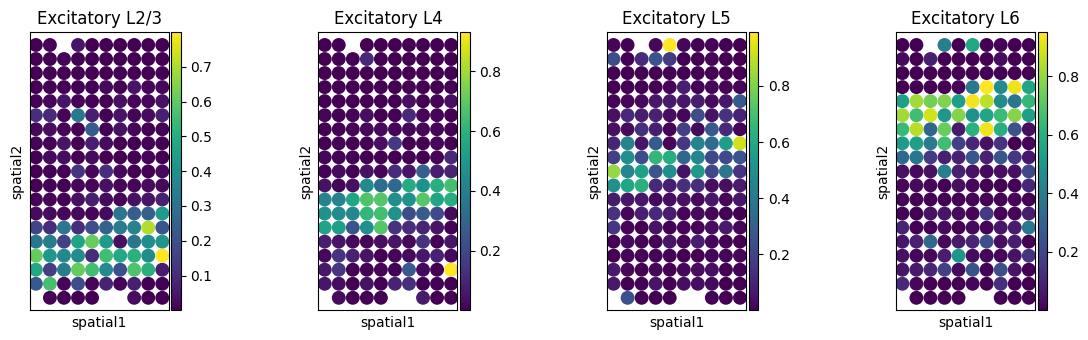

In [12]:
import matplotlib.pyplot as plt

celltypes = [
    'Excitatory L2/3',
    'Excitatory L4',
    'Excitatory L5',
    'Excitatory L6'
]

fig, axes = plt.subplots(1, 4, figsize=(12, 3.5))

for ax, celltype in zip(axes, celltypes):
    sc.pl.embedding(
        model.st_ad,
        basis="spatial",
        color=celltype,
        size=400,
        cmap="viridis",
        ax=ax,
        show=False
    )

    ax.set_aspect("equal")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

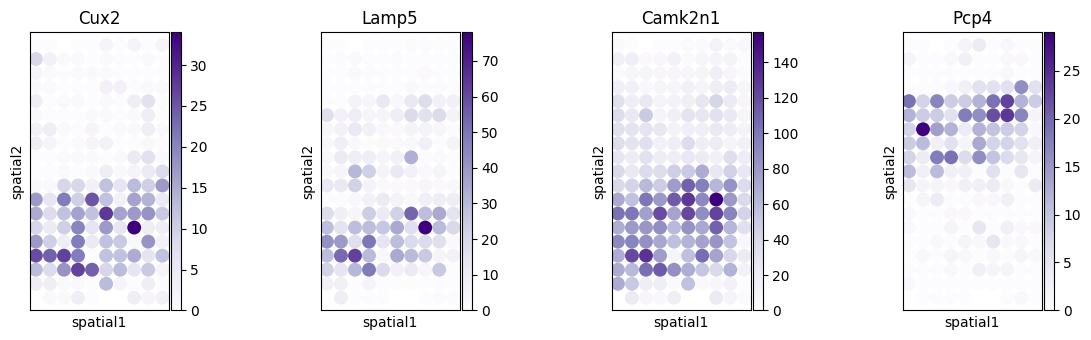

In [13]:
genes = ["Cux2", "Lamp5", "Camk2n1", "Pcp4"]

fig, axes = plt.subplots(
    1, 4,
    figsize=(12, 3.5)
)

for ax, gene in zip(axes, genes):
    sc.pl.embedding(
        model.st_ad,
        basis="spatial",
        color=gene,
        size=400,
        cmap="Purples",
        ax=ax,
        show=False,
        title=gene
    )

    ax.set_aspect("equal")
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

In [14]:
model.st_ad.write_h5ad('./results/simulated_starmap.h5ad')